In [4]:
#1. Imports and configuration

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
LABELS_PATH = "labels.csv"
IMAGES_ROOT = "."  # images folder is under current directory

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
EPOCHS = 20

os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)


In [ ]:
#2: Load labels

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\labels.csv")
df.head()


,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


Number of samples: 480

Class counts:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


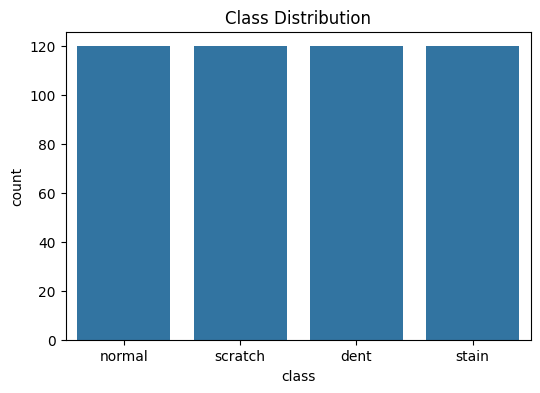

In [ ]:
#3: Class distribution

print("Number of samples:", len(df))
print("\nClass counts:")
print(df['class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class')
plt.title("Class Distribution")
plt.show()


Original image shape: (96, 96, 3)


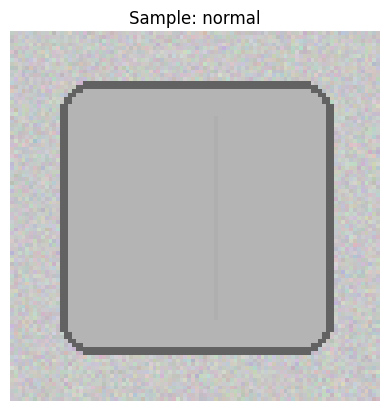

In [ ]:
#4: Inspect one sample image

sample_path = df['filename'].iloc[0]
full_path = os.path.join(IMAGES_ROOT, sample_path)

img = cv2.imread(full_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Original image shape:", img.shape)

plt.imshow(img_rgb)
plt.title(f"Sample: {df['class'].iloc[0]}")
plt.axis("off")
plt.show()


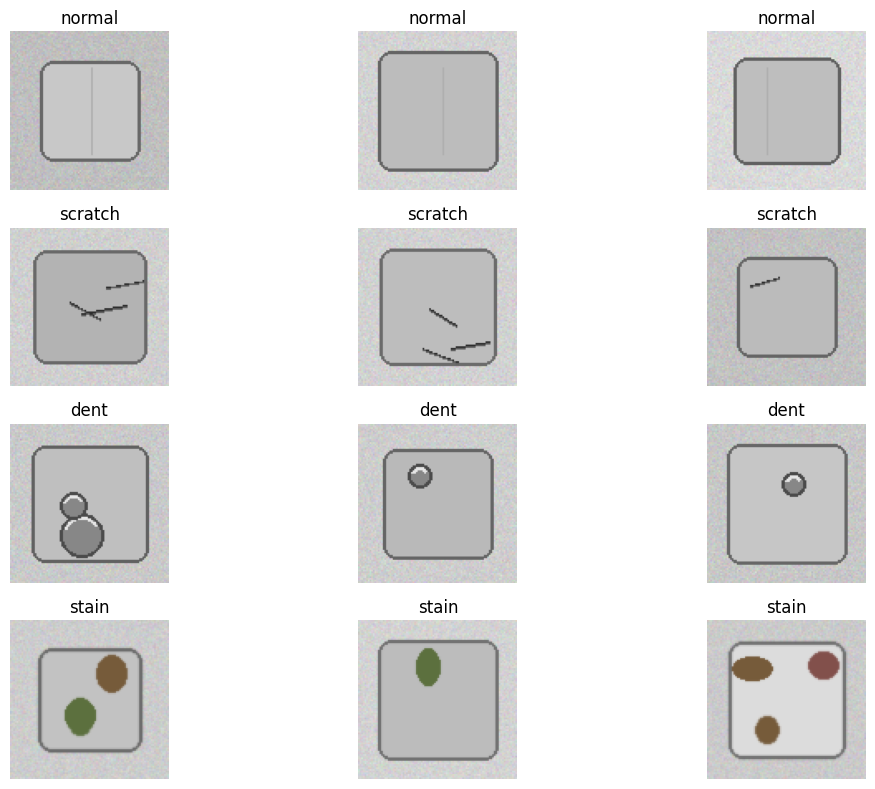

In [ ]:
#5: Show sample images from each class

classes = df['class'].unique()
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    cls_df = df[df['class'] == cls].sample(3, random_state=42)
    for j, (_, row) in enumerate(cls_df.iterrows()):
        img_path = os.path.join(IMAGES_ROOT, row['filename'])
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 3, i*3 + j + 1)
        plt.imshow(img_rgb)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
#6: Load all images into memory (for this small dataset it's fine)

def load_and_preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img.astype("float32") / 255.0
    return img

images = []
labels = []

for idx, row in df.iterrows():
    img_path = os.path.join(IMAGES_ROOT, row['filename'])
    img = load_and_preprocess_image(img_path)
    images.append(img)
    labels.append(row['class'])

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


Images shape: (480, 128, 128, 3)
Labels shape: (480,)


In [24]:
#7: Encode labels as integers

class_names = sorted(df['class'].unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y = np.array([class_to_idx[c] for c in labels])

print("Class to index mapping:", class_to_idx)


Class to index mapping: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [25]:
#8: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    images, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (384, 128, 128, 3) (384,)
Test shape: (96, 128, 128, 3) (96,)


In [26]:
#9: Data generators with augmentation for training

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train, y_train, batch_size=BATCH_SIZE, shuffle=True
)

val_generator = test_datagen.flow(
    X_test, y_test, batch_size=BATCH_SIZE, shuffle=False
)


In [28]:
#10: Build the CNN model

model = Sequential([
    tf.keras.Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#11: Train the model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.2656 - loss: 1.4812 - val_accuracy: 0.4167 - val_loss: 1.3813
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.2578 - loss: 1.3876 - val_accuracy: 0.4792 - val_loss: 1.3714
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.3490 - loss: 1.3464 - val_accuracy: 0.4583 - val_loss: 1.2578
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.5130 - loss: 1.1719 - val_accuracy: 0.6979 - val_loss: 0.9877
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.6172 - loss: 0.9105 - val_accuracy: 0.6667 - val_loss: 0.7845
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.6432 - loss: 0.7717 - val_accuracy: 0.7188 - val_loss: 0.6042
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.7188 - loss: 0.6386 - val_accuracy: 0.8333 - val_loss: 0.5370
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.7682 - loss: 0.5401 - val_accuracy: 0.

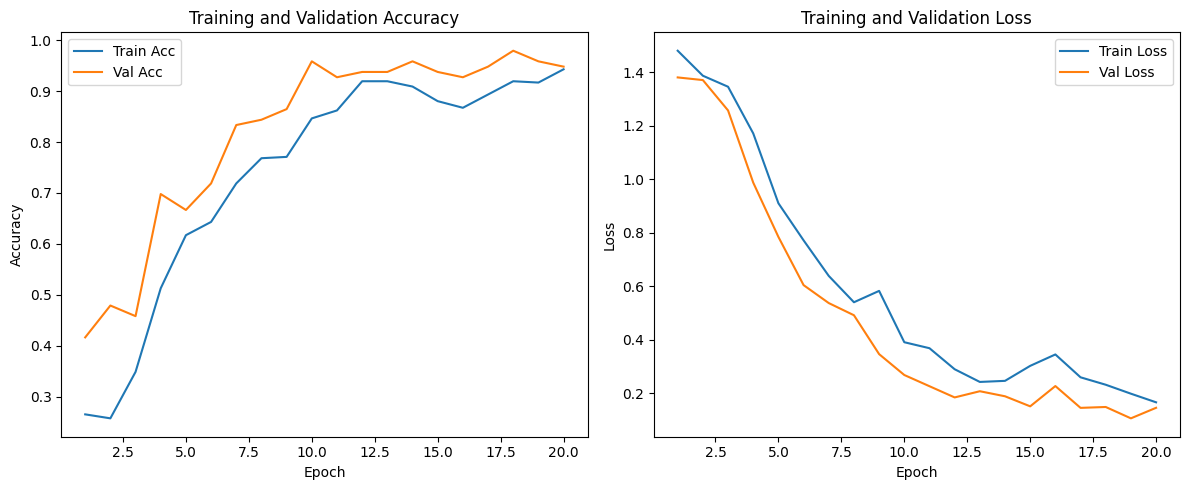

In [30]:
#12: Plot accuracy and loss curves

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.savefig("results/accuracy_loss_curves.png", dpi=150)
plt.show()


In [31]:
#13: Evaluate on test data

test_loss, test_acc = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9479 - loss: 0.1451
Test Loss: 0.1451
Test Accuracy: 0.9479


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


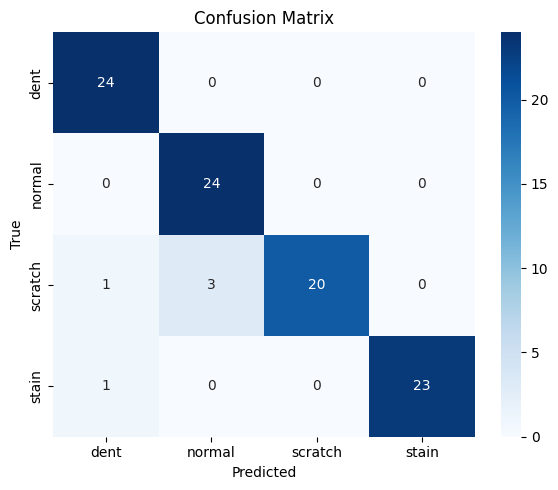


Classification Report:

              precision    recall  f1-score   support

        dent       0.92      1.00      0.96        24
      normal       0.89      1.00      0.94        24
     scratch       1.00      0.83      0.91        24
       stain       1.00      0.96      0.98        24

    accuracy                           0.95        96
   macro avg       0.95      0.95      0.95        96
weighted avg       0.95      0.95      0.95        96



In [32]:
#14: Confusion matrix

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


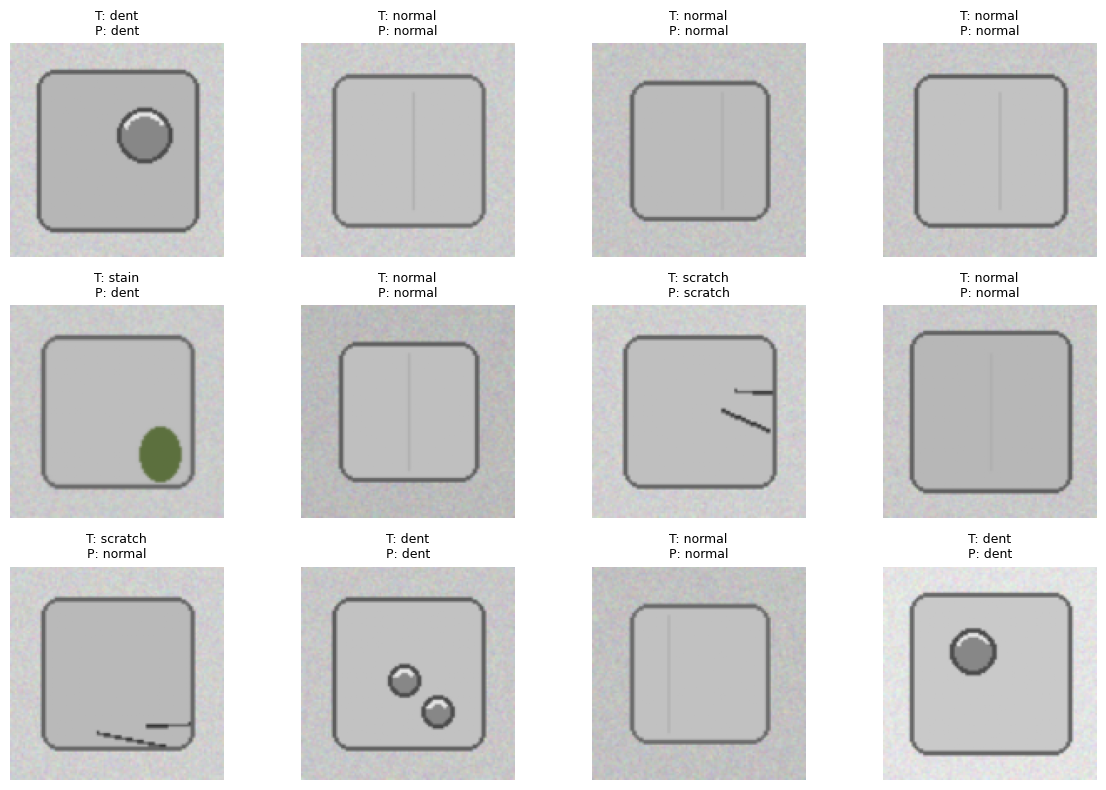

In [33]:
#15: Show sample predictions and save to file

num_samples = 12
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = idx_to_class[y_test[idx]]

    pred_prob = model.predict(img[np.newaxis, ...])[0]
    pred_idx = np.argmax(pred_prob)
    pred_label = idx_to_class[pred_idx]

    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=9)

plt.tight_layout()
plt.savefig("sample_predictions/prediction_outputs.png", dpi=150)
plt.show()
